# Supermarket sales with MDMP: learning product networks over time

A category manager at a supermarket wants to understand how **daily unit sales
of 15 products** move together over the first half of 2024. The practical
questions are familiar:

- Which items tend to sell together (complements) versus instead of one another
  (substitutes)?
- Are those relationships stable, or do they drift with promotions and seasons?
- Which days look unusual relative to the rest of the panel?
- Does the **shelf taxonomy** (class → family → SKU) already capture the
  structure, or do we learn something extra by treating every product as its
  own node?

This notebook is the main practical example of **MDMP**. It uses the bundled
retail panel (`load_retail()`), learns a contemporaneous Bayesian network with
time-varying coefficients (`MDM`), and then changes the granularity (SKUs,
product classes, months, and food groups) to see how the story changes.

Graph DAG plots (`plot_dag(..., plot_type="graph")`) use Graphviz `dot` by
default. If `dot` is not on PATH, pass `style="networkx"` instead.


In [ ]:
!pip install git+https://github.com/maods2/mdmp.git

In [6]:
%matplotlib inline

from IPython.display import display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from mdmp.model import MDM
from mdmp.retail import (
    C3_LABELS, C4_LABELS, DAG_LABELS, SKU_DAG_LABELS,
    aggregate_by_level, cohort_summary, food_group_subjects,
    load_retail, monthly_subjects, one_sku_per_type,
)
from mdmp.plotting import (
    plot_anomalies, plot_arcs, plot_dag, plot_marginal, plot_mdp, plot_stream,
)
from mdmp.anomaly import detect_anomalies
from mdmp.group_analysis import (
    compute_gs, compute_is, compute_vts,
    fit_individual_structures, suggest_clusters,
)

NBF = 15
NBF_MONTHLY = 10  # each calendar month has only ~28–31 days
CI_LEVEL = 0.95
plt.rcParams["figure.figsize"] = (10, 5)


## 1. The supermarket and the dataset

The data shipped with MDMP is a **hypothetical supermarket sales panel**: 15
stock-keeping units (SKUs) observed every day from 1 January to 28 June 2024
(180 days). Each SKU is a contemporaneous **response series** — daily unit
sales — not a static covariate.

MDMP does not split variables into a block of seven cross-sectional regressors
and seven temporal responses. All 15 SKU columns enter the model as nodes in
one contemporaneous DAG. The **seven product classes** (C3) are taxonomy
labels used to group and aggregate SKUs; they are not extra regressors.

`load_retail()` returns two frames:

- `sales`: `Time` plus one column per SKU (`Line|Item`).
- `hierarchy`: index = SKU name; columns `type` (class), `line` (family),
  `item` (pack / size).


In [7]:
sales, hierarchy = load_retail()
skus = [c for c in sales.columns if c != "Time"]

print(sales.shape, f"{sales['Time'].min().date()} -> {sales['Time'].max().date()}")
print(
    f"{len(skus)} SKUs | classes (C3 type): {hierarchy['type'].nunique()} | "
    f"families (C4 line): {hierarchy['line'].nunique()}"
)

catalog = pd.DataFrame(
    {
        "sku": skus,
        "english": [SKU_DAG_LABELS.get(s, s) for s in skus],
        "class": [C3_LABELS.get(hierarchy.loc[s, "type"], hierarchy.loc[s, "type"]) for s in skus],
        "family": [C4_LABELS.get(hierarchy.loc[s, "line"], hierarchy.loc[s, "line"]) for s in skus],
        "item": hierarchy.loc[skus, "item"].tolist(),
    }
)
display(catalog)
display(sales.head())


(180, 16) 2024-01-01 -> 2024-06-28
15 SKUs | classes (C3 type): 7 | families (C4 line): 12


,sku,english,class,family,item
0,Cerveja|Lata,Beer-can,Alcoholic beverages,Beer,Lata
1,Cerveja|Latao,Beer-large,Alcoholic beverages,Beer,Latao
2,Cerveja|Retornavel 250ml,Beer-ret,Alcoholic beverages,Beer,Retornavel 250ml
3,Arroz|5kg,Rice,Basic cereals,Rice,5kg
4,Feijao|1kg,Beans,Basic cereals,Beans,1kg
5,Pao|Forma,Bread,Bakery,Bread,Forma
6,Oleo_Soja|1L,Soy oil,Preserves,Soybean oil,1L
7,Molho_Tomate|250g,Tomato,Preserves,Tomato sauce,250g
8,Leite|Integral,Milk,Dairy,Milk,Integral
9,Iogurte|Natural,Yogurt,Dairy,Yogurt,Natural


,Time,Cerveja|Lata,Cerveja|Latao,Cerveja|Retornavel 250ml,Arroz|5kg,Feijao|1kg,Pao|Forma,Oleo_Soja|1L,Molho_Tomate|250g,Leite|Integral,Iogurte|Natural,Refrigerante|Retornavel 1.5L,Refrigerante|Lata,Suco_Natural|1L,Cereal_Barra|250g,Chocolate|Leite 1kg
0,2024-01-01,138,53,80,79,111,101,83,110,153,76,98,97,55,54,30
1,2024-01-02,128,65,96,71,89,107,92,93,132,79,122,144,50,65,62
2,2024-01-03,133,63,66,68,85,97,83,98,126,87,54,107,85,65,67
3,2024-01-04,147,59,81,84,102,99,76,83,130,57,98,84,59,63,57
4,2024-01-05,156,101,125,90,105,137,90,88,160,90,92,165,59,84,59


**What each column means**

| Piece | Role |
| --- | --- |
| `Time` | Calendar day (the time index). Drop it before fitting `MDM`. |
| 15 SKU columns | Daily unit sales. These are the MDM nodes. |
| `hierarchy.type` | Product **class** (C3): 7 groups such as alcoholic beverages. |
| `hierarchy.line` | Product **family** (C4): 12 groups such as beer or soft drinks. |
| `hierarchy.item` | Pack / size (can, 5 kg, 1 L, …). |

The next section shows how those labels nest. We will **not** use them in the
first MDM fit, that is the “treat products as independent nodes” baseline.


## 2. How products nest: class → family → SKU

The assortment is a three-level tree:

1. **Class** (`hierarchy.type`, C3) — 7 groups (alcoholic beverages, dairy, …).
2. **Family** (`hierarchy.line`, C4) — 12 groups nested inside classes (beer
   under alcoholic beverages, milk under dairy, …).
3. **SKU** (`item`) — 15 leaf products.

`aggregate_by_level(sales, hierarchy, level_column)` is the library helper that
sums SKUs inside a level. `level_column="type"` yields **7 class-level series**;
`level_column="line"` yields **12 family-level series**. Structure learning
does **not** constrain the DAG to this taxonomy: `plot_dag(..., hierarchical=True)`
is only a layout option, not a product-hierarchy constraint.


Classes (C3) and the SKUs they contain:
  Alcoholic beverages: Beer-can, Beer-large, Beer-ret
  Basic cereals: Rice, Beans
  Bakery: Bread
  Preserves: Soy oil, Tomato
  Dairy: Milk, Yogurt
  Non-alcoholic beverages: Soda-1.5L, Soda-can, Juice
  Biscuits and confectionery: Cereal bar, Chocolate


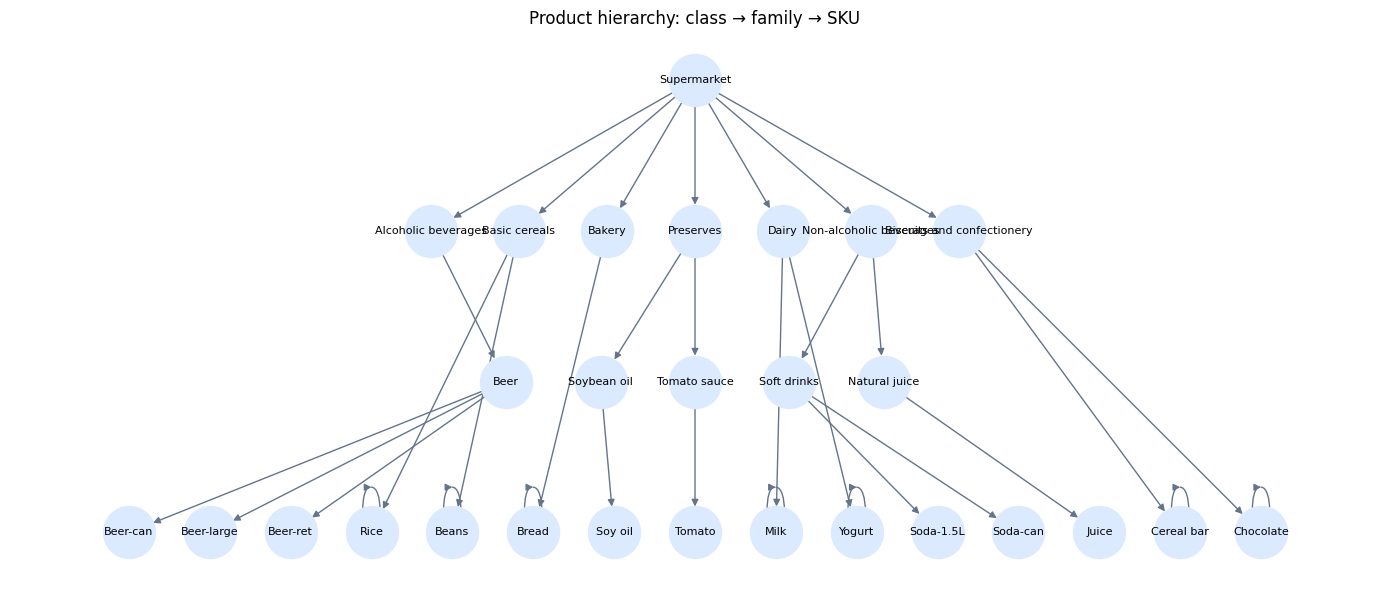

Class-level panel (C3): (180, 7) ['Alcoholic beverages', 'Basic cereals', 'Bakery', 'Preserves', 'Dairy', 'Non-alcoholic beverages', 'Biscuits and confectionery']
Family-level panel (C4): (180, 12) ['Beer', 'Rice', 'Beans', 'Bread', 'Soybean oil', 'Tomato sauce', 'Milk', 'Yogurt', 'Soft drinks', 'Natural juice', 'Cereal bar', 'Chocolate']


In [8]:
print("Classes (C3) and the SKUs they contain:")
for cls, group in hierarchy.groupby("type", sort=False):
    cls_en = C3_LABELS.get(cls, cls)
    items = ", ".join(SKU_DAG_LABELS.get(s, s) for s in group.index)
    print(f"  {cls_en}: {items}")

# Taxonomy tree (NetworkX / Matplotlib — not plot_dag).
G = nx.DiGraph()
root = "Supermarket"
for sku, row in hierarchy.iterrows():
    cls = C3_LABELS.get(row["type"], row["type"])
    fam = C4_LABELS.get(row["line"], row["line"])
    leaf = SKU_DAG_LABELS.get(sku, sku)
    G.add_edge(root, cls)
    G.add_edge(cls, fam)
    G.add_edge(fam, leaf)

layers = {root: 0}
for sku, row in hierarchy.iterrows():
    layers[C3_LABELS.get(row["type"], row["type"])] = 1
    layers[C4_LABELS.get(row["line"], row["line"])] = 2
    layers[SKU_DAG_LABELS.get(sku, sku)] = 3

pos = {}
for level in range(4):
    nodes = [n for n, lv in layers.items() if lv == level]
    xs = np.linspace(-len(nodes) / 2, len(nodes) / 2, num=len(nodes)) if len(nodes) > 1 else [0.0]
    for x, n in zip(xs, nodes):
        pos[n] = (float(x), -float(level))

fig, ax = plt.subplots(figsize=(14, 6))
nx.draw_networkx(
    G,
    pos=pos,
    ax=ax,
    node_size=1400,
    font_size=8,
    arrows=True,
    node_color="#dbeafe",
    edge_color="#64748b",
)
ax.set_title("Product hierarchy: class → family → SKU")
ax.axis("off")
fig.tight_layout()
plt.show()

c3 = aggregate_by_level(sales, hierarchy, "type")
c4 = aggregate_by_level(sales, hierarchy, "line")
print("Class-level panel (C3):", c3.shape, list(c3.columns))
print("Family-level panel (C4):", c4.shape, list(c4.columns))


The tree is the manager’s shelf map. The next model **ignores it**: every SKU
is a node, with no requirement that beer cans only connect to other beers.
That is the honest baseline — if the learned DAG later lines up with classes,
that is a finding, not an assumption.


## 3. First model: treat the 15 SKUs as independent nodes

Fit one MDM on the full product panel. Parents at time \(t\) enter the child’s
regression at the same \(t\); the dynamics live in the DLM coefficients, not in
lagged DAG edges.

We use hill-climbing (`method="hc"`), a 15-day burn-in (`nbf=15`), and all
CPU cores (`n_jobs=-1`). Discount factors \(\delta\) are chosen per node by
maximizing log predictive likelihood.


In [9]:
sku_order = hierarchy.sort_values(["type", "line", "item"]).index.tolist()
panel = sales.loc[:, sku_order].copy()
panel.index = sales["Time"]

product_mdm = MDM(panel, method="hc", nbf=NBF, verbose=False, n_jobs=-1)
print("edges:", int(np.sum(product_mdm.adj_mat)))
print("node order:", [SKU_DAG_LABELS.get(s, s) for s in sku_order])
print("DF_hat:", np.round(product_mdm.DF["DF_hat"], 3))


edges: 24
node order: ['Beer-can', 'Beer-large', 'Beer-ret', 'Rice', 'Beans', 'Tomato', 'Soy oil', 'Yogurt', 'Milk', 'Soda-can', 'Soda-1.5L', 'Juice', 'Bread', 'Cereal bar', 'Chocolate']
DF_hat: [0.5  1.   1.   1.   0.98 0.98 0.97 0.98 0.97 1.   0.98 1.   0.97 0.88
 0.5 ]


`DF_hat` close to 1 means a relatively stable local regression for that SKU;
smaller values allow the coefficients to move faster. Edges are empirical:
nothing in this fit forced two beers to share a parent just because they sit
on the same shelf.


## 4. What the library produced: the SKU network

`plot_dag` shows the contemporaneous graph (and a heatmap of the adjacency).
`plot_arcs` then shows how the selected parent→child coefficients move through
the 180 days. If Graphviz `dot` is missing, switch `style` to `"networkx"`.


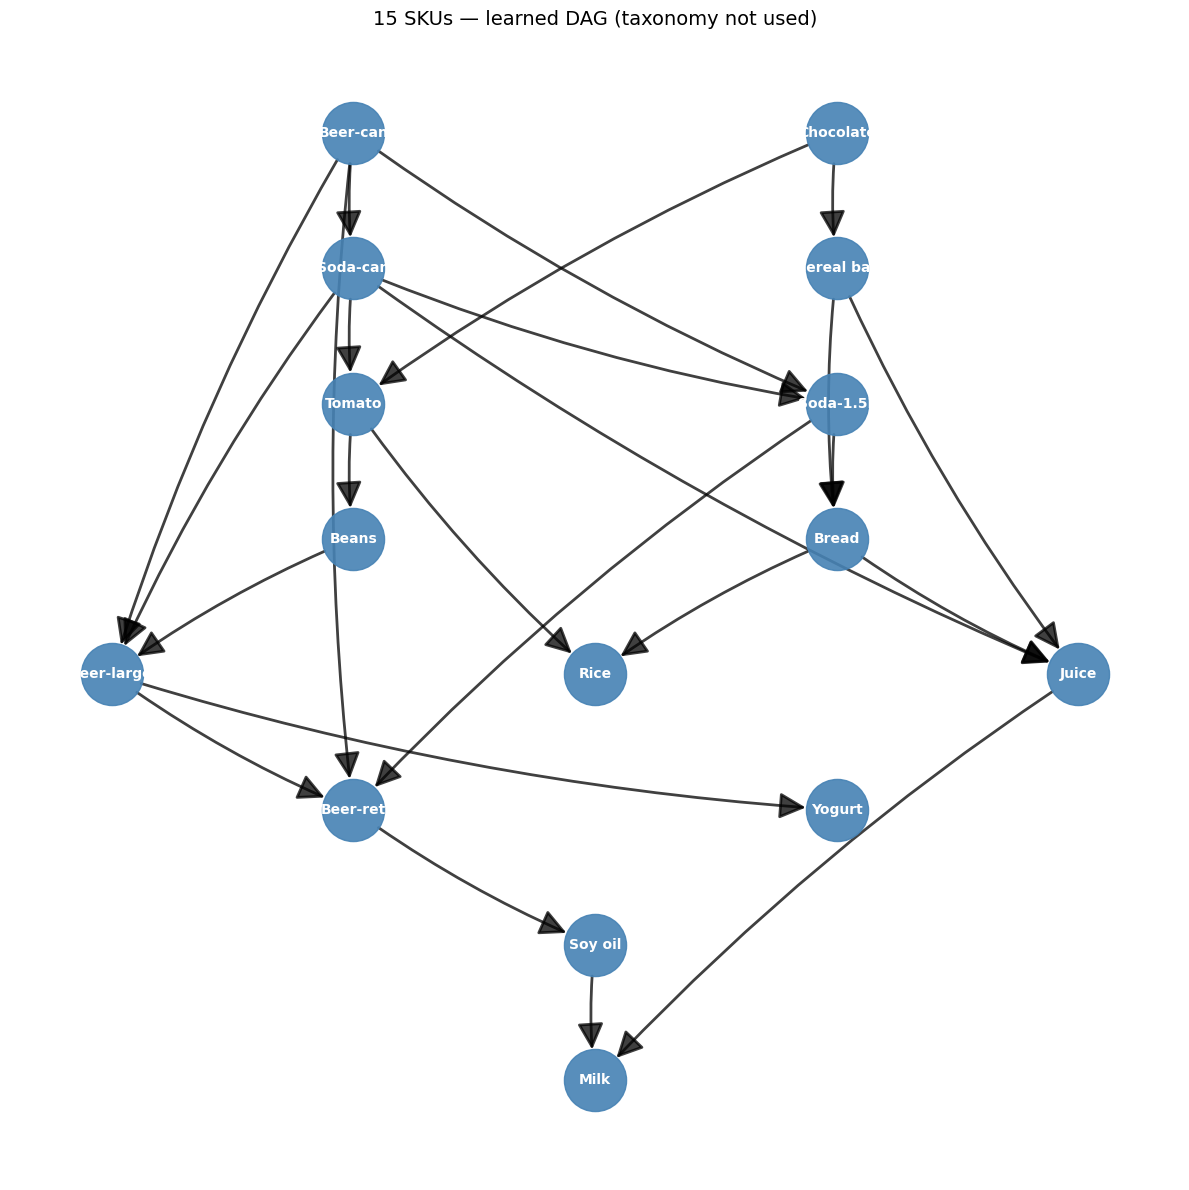

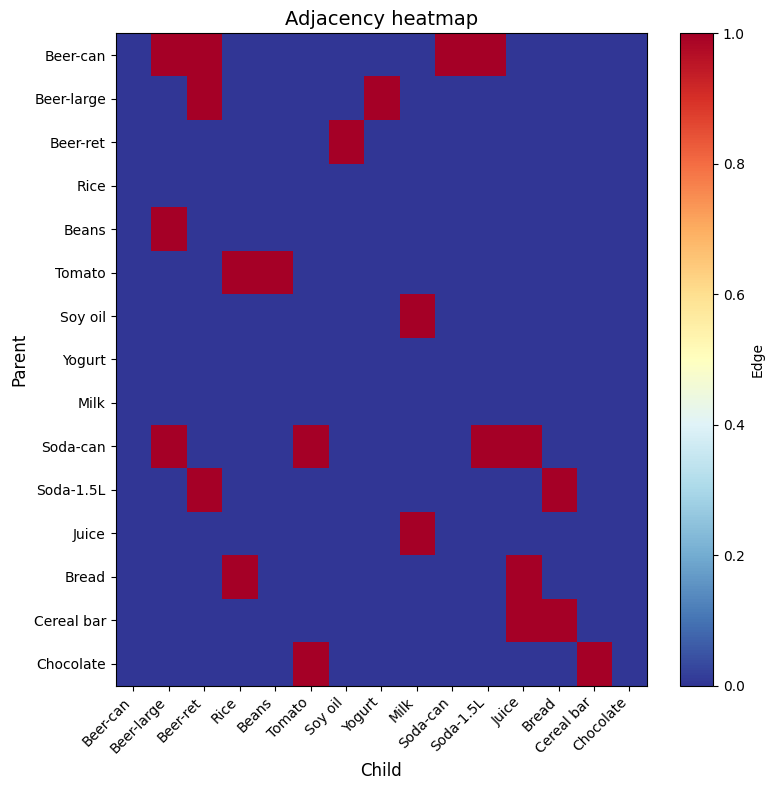

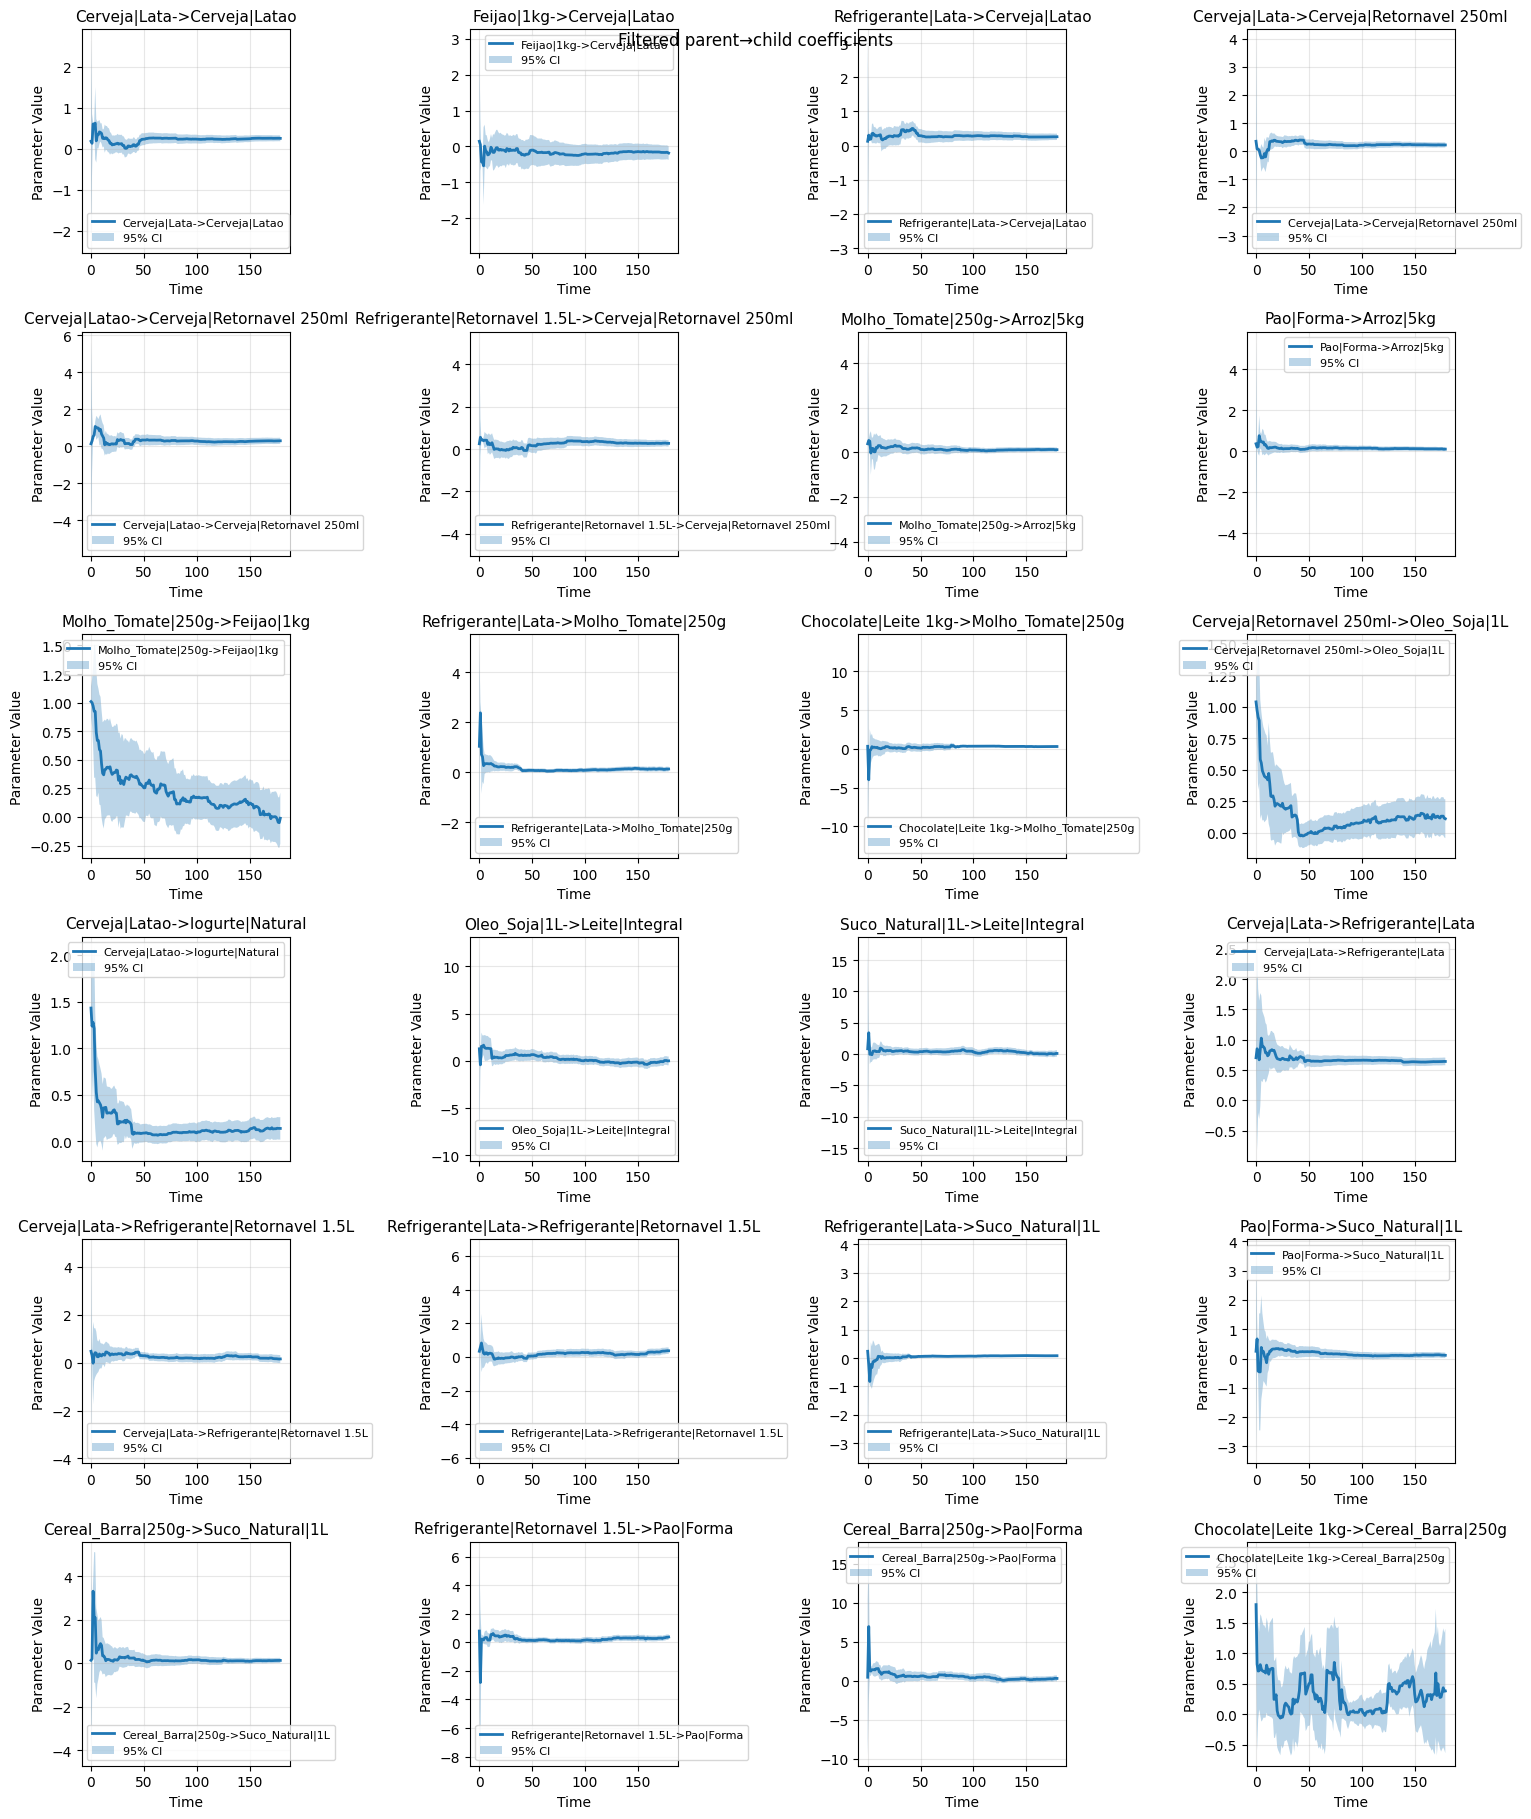

In [10]:
short_labels = [SKU_DAG_LABELS.get(s, s) for s in sku_order]

fig = plot_dag(
    product_mdm,
    node_labels=short_labels,
    style="networkx",
    title="15 SKUs — learned DAG (taxonomy not used)",
)
plt.show()

fig = plot_dag(
    product_mdm,
    node_labels=short_labels,
    plot_type="heatmap",
    title="Adjacency heatmap",
)
plt.show()

fig = plot_arcs(product_mdm, plot_type="connections", distribution="filt", ci_level=CI_LEVEL)
plt.suptitle("Filtered parent→child coefficients")
plt.show()


Arrows are same-day predictive relationships, not delayed supply-chain lags.
A dense cluster among beverages, for example, would suggest that those SKUs
share demand shocks (weather, weekend traffic, a multi-buy) even though we
did not tell the model they belong to the same class.


## 5. A closer look at one product

Pick the SKU with the most parents — the item whose sales the network
explains using the largest number of contemporaneous series. For that child
we inspect:

- **Stream plot**: stacked parent contributions over time.
- **Marginal posterior**: how each coefficient (and the intercept) evolves.
- **Anomalies**: days outside the one-step Student-t predictive interval.

The anomaly table still uses this **SKU-level** model. Classes only reorder
the counts so the manager can see whether unusual days concentrate in one
aisle.


focus SKU: Beer-large | family: Beer | n_parents: 3


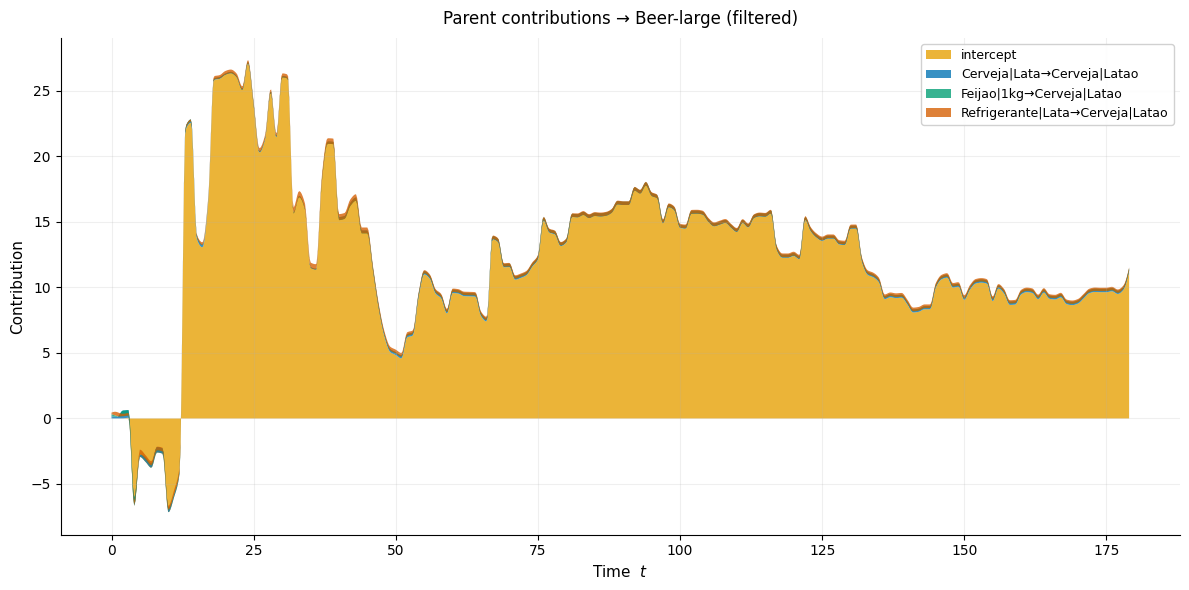

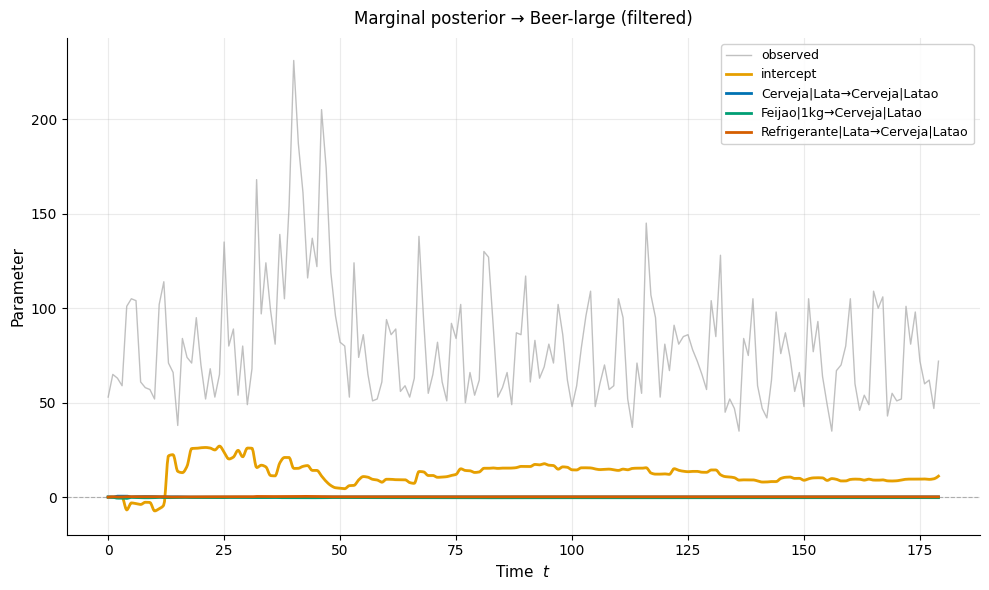

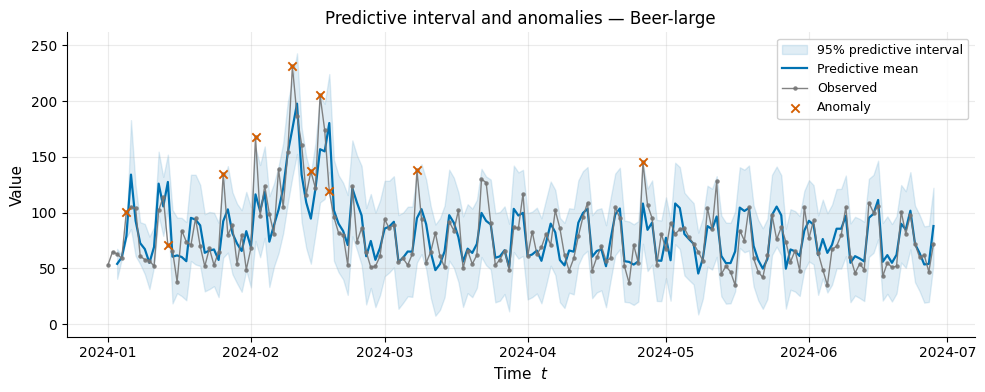

total anomaly flags: 128 / 2700


,english,class,family,n_anomalies
sku,,,,
Cerveja|Retornavel 250ml,Beer-ret,Alcoholic beverages,Beer,14
Cereal_Barra|250g,Cereal bar,Biscuits and confectionery,Cereal bar,13
Suco_Natural|1L,Juice,Non-alcoholic beverages,Natural juice,12
Chocolate|Leite 1kg,Chocolate,Biscuits and confectionery,Chocolate,11
Refrigerante|Lata,Soda-can,Non-alcoholic beverages,Soft drinks,10
Cerveja|Latao,Beer-large,Alcoholic beverages,Beer,10
Pao|Forma,Bread,Bakery,Bread,8
Refrigerante|Retornavel 1.5L,Soda-1.5L,Non-alcoholic beverages,Soft drinks,7
Molho_Tomate|250g,Tomato,Preserves,Tomato sauce,7


anomalies by class:


,n_anomalies
class,
Alcoholic beverages,31
Non-alcoholic beverages,29
Biscuits and confectionery,24
Preserves,13
Basic cereals,13
Dairy,10
Bakery,8


In [11]:
adj = np.asarray(product_mdm.adj_mat)
parents_per_child = adj.sum(axis=0)
child_idx = int(np.argmax(parents_per_child)) if parents_per_child.max() > 0 else 0
child_name = sku_order[child_idx]
child_en = SKU_DAG_LABELS.get(child_name, child_name)
print(
    "focus SKU:",
    child_en,
    "| family:",
    C4_LABELS.get(hierarchy.loc[child_name, "line"], hierarchy.loc[child_name, "line"]),
    "| n_parents:",
    int(parents_per_child[child_idx]),
)

plot_stream(
    product_mdm,
    child_node=child_idx,
    distribution="filt",
    title=f"Parent contributions → {child_en} (filtered)",
)
plt.show()

plot_marginal(
    product_mdm,
    target_node=child_idx,
    distribution="filt",
    title=f"Marginal posterior → {child_en} (filtered)",
)
plt.show()

fig = plot_anomalies(
    product_mdm,
    series=child_name,
    ci_level=CI_LEVEL,
    time_index=sales["Time"],
)
plt.title(f"Predictive interval and anomalies — {child_en}")
plt.show()

anom = detect_anomalies(product_mdm, ci_level=CI_LEVEL, output="dataframe")
counts = (
    anom.groupby("node")["is_anomaly"]
    .sum()
    .astype(int)
    .rename("n_anomalies")
    .sort_values(ascending=False)
)
summary = catalog.set_index("sku").join(counts)
print(f"total anomaly flags: {int(anom['is_anomaly'].sum())} / {len(anom)}")
display(summary[["english", "class", "family", "n_anomalies"]].sort_values("n_anomalies", ascending=False))
print("anomalies by class:")
display(summary.groupby("class")["n_anomalies"].sum().sort_values(ascending=False).to_frame())


Flagged days are observations the one-step forecast did not expect — a
promotion spike, a stockout, or a demand shock that the current parents did
not absorb. Comparing class totals (without refitting) is only a reading aid:
the model still treats every SKU as its own node.


## 6. What changes if we vary the view?

Three variations, in order:

1. **Filtered vs smoothed** posteriors for the same child — smoothing uses
   the whole sample and typically damps day-to-day noise.
2. **A second SKU**, preferably in the same family, to see whether the
   stream/marginal story is item-specific.
3. **Bring the hierarchy back in** via `aggregate_by_level`. Fitting MDM on
   the 7 class series asks a coarser question: how do *aisles* move together,
   not how do individual packs substitute.


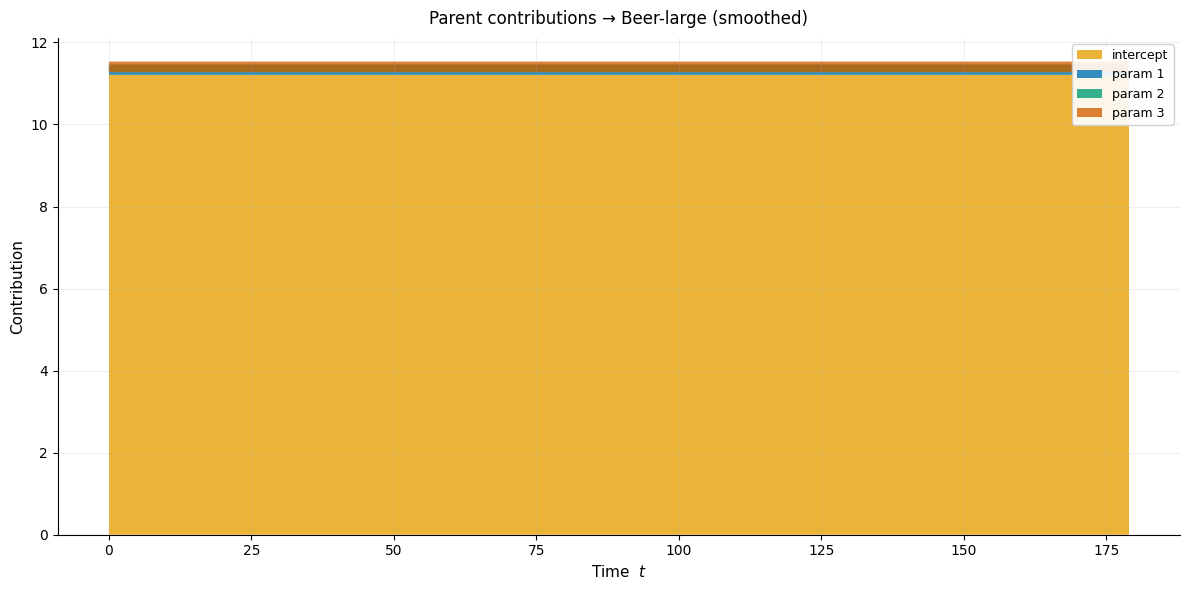

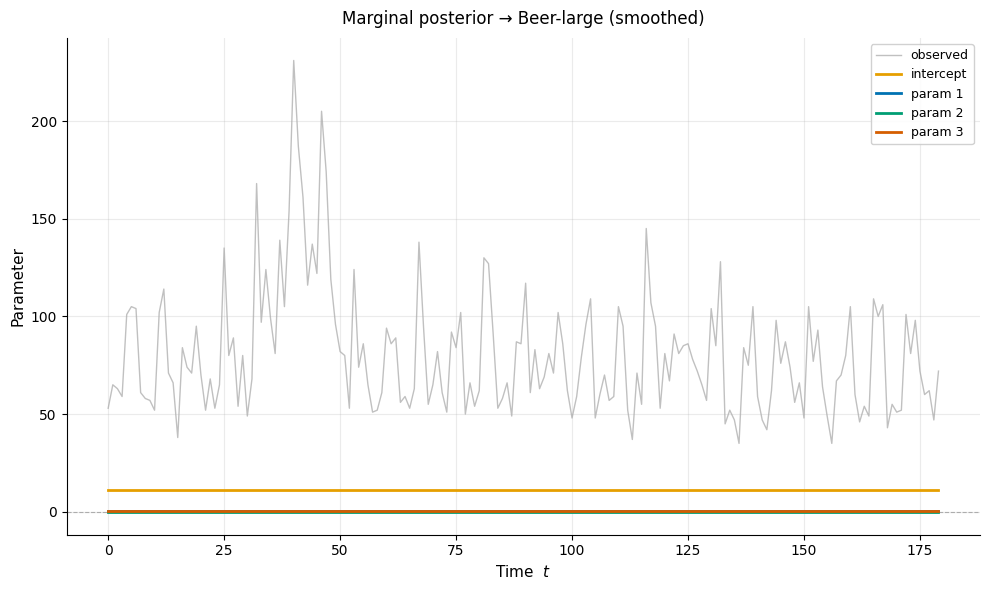

In [12]:
plot_stream(
    product_mdm,
    child_node=child_idx,
    distribution="smoo",
    title=f"Parent contributions → {child_en} (smoothed)",
)
plt.show()

plot_marginal(
    product_mdm,
    target_node=child_idx,
    distribution="smoo",
    title=f"Marginal posterior → {child_en} (smoothed)",
)
plt.show()


second SKU: Beer-can | family: Beer | n_parents: 0


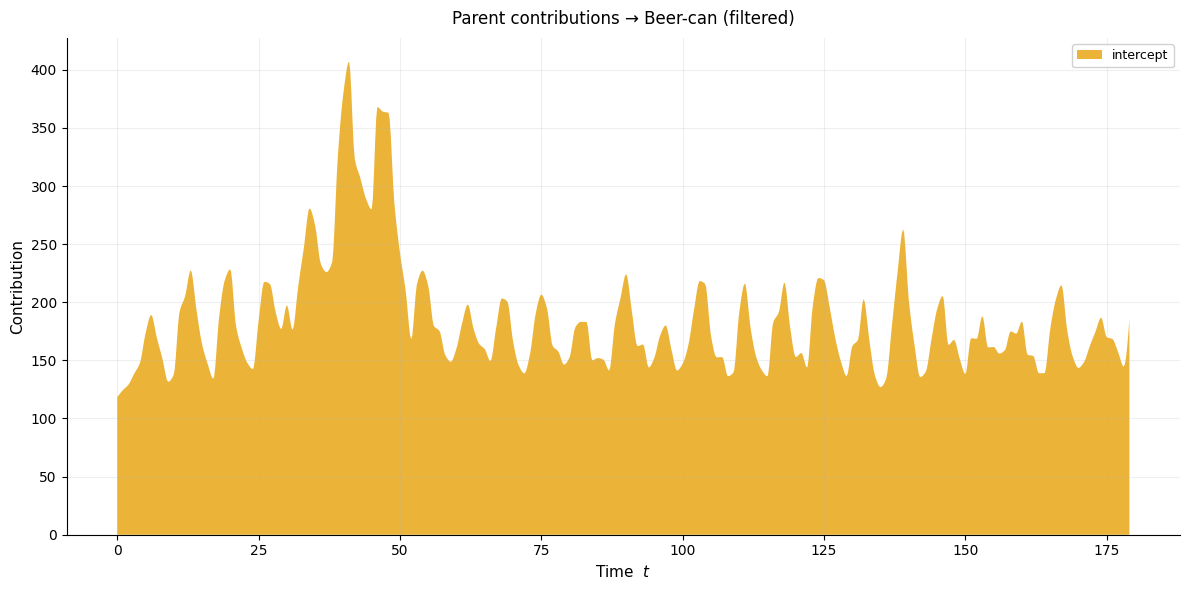

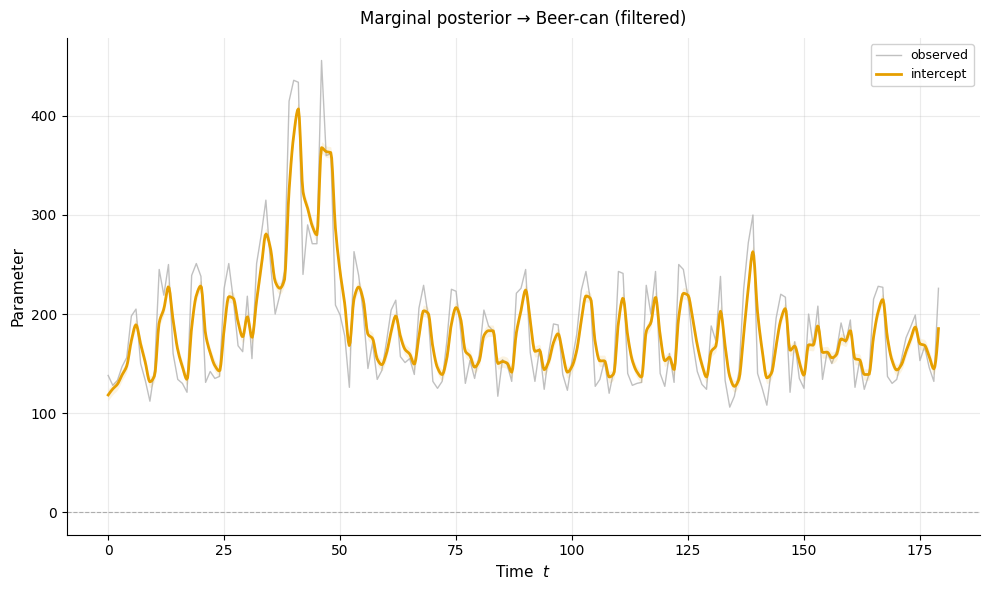

In [13]:
child_line = hierarchy.loc[child_name, "line"]
same_family = [s for s in sku_order if hierarchy.loc[s, "line"] == child_line and s != child_name]
if same_family:
    alt_name = same_family[0]
else:
    ranked = np.argsort(-parents_per_child)
    alt_name = sku_order[int(ranked[1])] if len(ranked) > 1 else child_name
alt_idx = sku_order.index(alt_name)
alt_en = SKU_DAG_LABELS.get(alt_name, alt_name)
print(
    "second SKU:",
    alt_en,
    "| family:",
    C4_LABELS.get(hierarchy.loc[alt_name, "line"], hierarchy.loc[alt_name, "line"]),
    "| n_parents:",
    int(parents_per_child[alt_idx]),
)

plot_stream(
    product_mdm,
    child_node=alt_idx,
    distribution="filt",
    title=f"Parent contributions → {alt_en} (filtered)",
)
plt.show()

plot_marginal(
    product_mdm,
    target_node=alt_idx,
    distribution="filt",
    title=f"Marginal posterior → {alt_en} (filtered)",
)
plt.show()


Now use the taxonomy. Summing SKUs inside each class (`level_column="type"`)
produces seven English-named series — one per aisle. The family-level panel
(`"line"`) is the intermediate 12-node view. These DAGs are **not** constrained
to the tree; they are new models on aggregated sales.


C3 class DAG edges: 8 | nodes: ['Alcoholic beverages', 'Basic cereals', 'Bakery', 'Preserves', 'Dairy', 'Non-alcoholic beverages', 'Biscuits and confectionery']


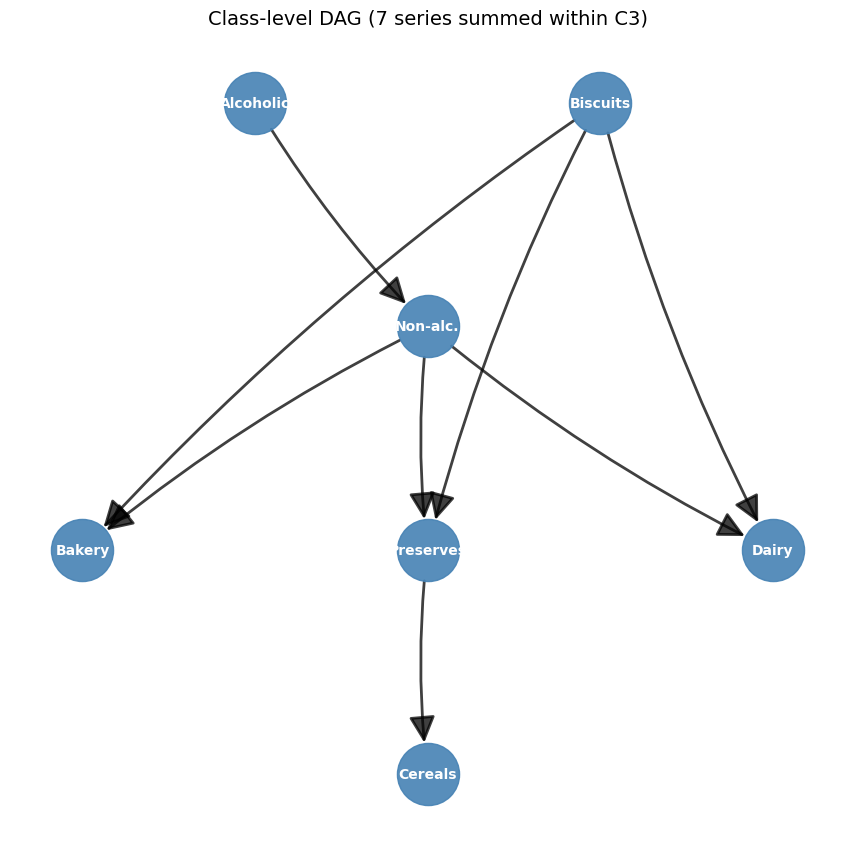

C4 family DAG edges: 16 | nodes: ['Beer', 'Rice', 'Beans', 'Bread', 'Soybean oil', 'Tomato sauce', 'Milk', 'Yogurt', 'Soft drinks', 'Natural juice', 'Cereal bar', 'Chocolate']


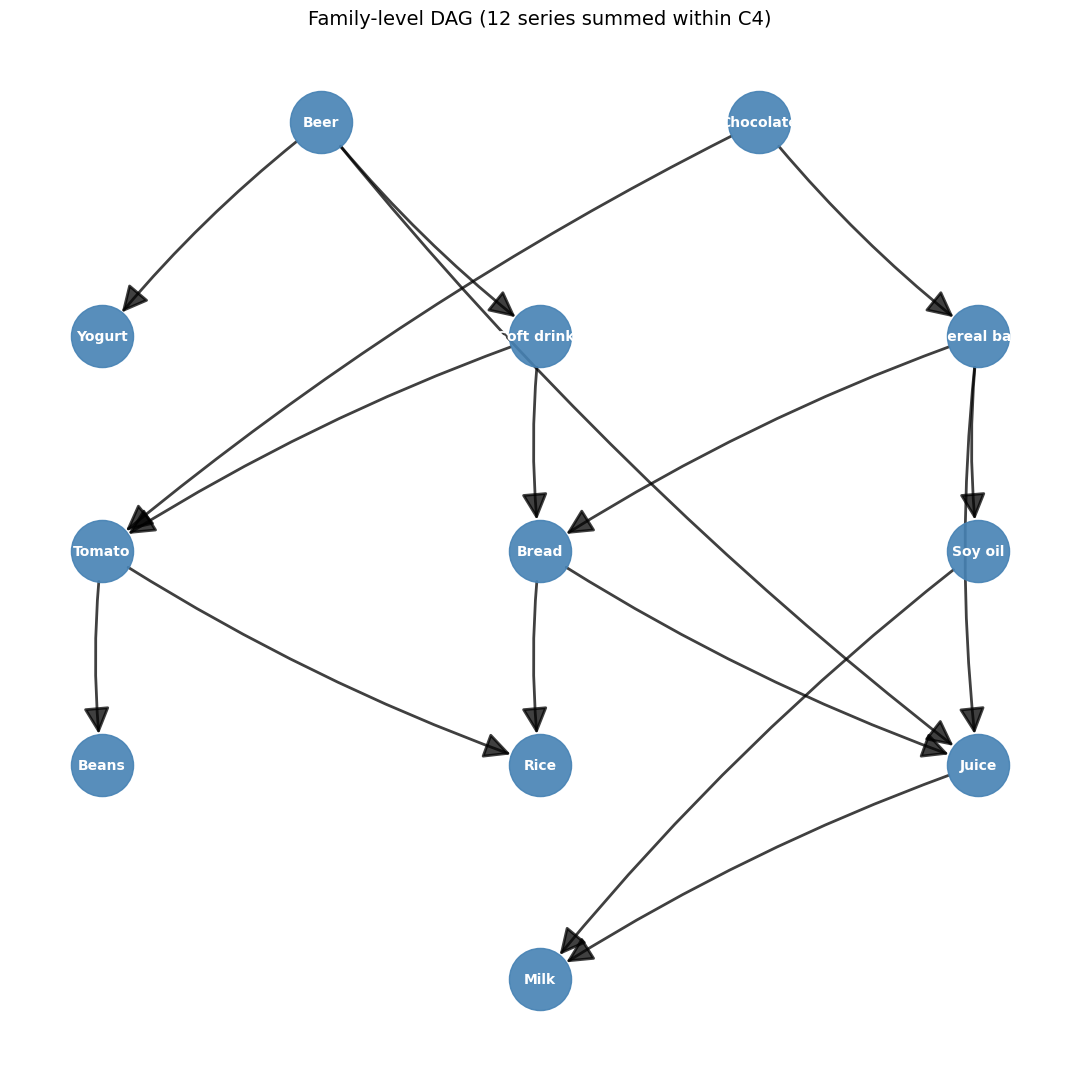

In [15]:
c3_data = aggregate_by_level(sales, hierarchy, "type")
c4_data = aggregate_by_level(sales, hierarchy, "line")

c3_mdm = MDM(c3_data, method="hc", nbf=NBF, verbose=False, n_jobs=-1)
c3_labels = [DAG_LABELS.get(n, n) for n in c3_mdm.node_names]
print("C3 class DAG edges:", int(np.sum(c3_mdm.adj_mat)), "| nodes:", list(c3_data.columns))
fig = plot_dag(
    c3_mdm,
    node_labels=c3_labels,
    style="networkx",
    title="Class-level DAG (7 series summed within C3)",
)
plt.show()

c4_mdm = MDM(c4_data, method="hc", nbf=NBF, verbose=False, n_jobs=-1)
c4_labels = [DAG_LABELS.get(n, n) for n in c4_mdm.node_names]
print("C4 family DAG edges:", int(np.sum(c4_mdm.adj_mat)), "| nodes:", list(c4_data.columns))
fig = plot_dag(
    c4_mdm,
    node_labels=c4_labels,
    style="networkx",
    title="Family-level DAG (12 series summed within C4)",
)
plt.show()


SKU-level graphs speak to **item substitution** (can vs returnable bottle).
Class-level graphs speak to **aisle demand** (beverages vs staples). If an
edge survives aggregation, it is a category-level co-movement, not just a
pack-size effect.


## 7. Do months and categories share a structure?

The single 180-day DAG averages over January weekends and June heat. Two
group-analysis tools split that panel into **subjects**:

- **Months as individuals.** Keep one SKU per class so node meaning is shared
  (`one_sku_per_type`). **VTS** averages the six monthly panels and fits one
  MDM; **IS** votes the six DAGs into a consensus graph (`tau=0.5`).
- **Food groups as individuals.** Five equal-size baskets (`N=3`) cover all
  15 SKUs. **GS** distance then asks which shelves behave alike, even though
  the three node slots are not the same products.

Deeper IS / VTS / GS case studies live in
[04-is-vs-vts-multi-individual.ipynb](04-is-vs-vts-multi-individual.ipynb) and
[09-gs-clusters-then-vts-is.ipynb](09-gs-clusters-then-vts-is.ipynb).


In [16]:
monthly_nodes = one_sku_per_type(hierarchy)
monthly_labels = [SKU_DAG_LABELS.get(s, s) for s in monthly_nodes]
print("monthly nodes (1 SKU per class):")
for sku, lab in zip(monthly_nodes, monthly_labels):
    print(f"  {lab:12}  {sku}  [{hierarchy.loc[sku, 'type']}]")

subjects_m, subject_ids_m, node_names_m = monthly_subjects(sales, node_names=monthly_nodes)
print(cohort_summary(subjects_m, subject_ids_m, node_names_m))


monthly nodes (1 SKU per class):
  Beer-can      Cerveja|Lata  [Alcoolicas]
  Rice          Arroz|5kg  [Cereais Básicos]
  Bread         Pao|Forma  [Padaria]
  Soy oil       Oleo_Soja|1L  [Conservas]
  Milk          Leite|Integral  [Leite]
  Soda-1.5L     Refrigerante|Retornavel 1.5L  [Não-alcoólicas]
  Cereal bar    Cereal_Barra|250g  [biscoitos, bomboniere]
{'n_subjects': 6, 'n_nodes': 7, 'node_names': ['Cerveja|Lata', 'Arroz|5kg', 'Pao|Forma', 'Oleo_Soja|1L', 'Leite|Integral', 'Refrigerante|Retornavel 1.5L', 'Cereal_Barra|250g'], 'subject_ids': ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06'], 'T_per_subject': [31, 29, 31, 30, 31, 28], 'T_min': 28, 'T_max': 31, 'shapes': [(31, 7), (29, 7), (31, 7), (30, 7), (31, 7), (28, 7)]}


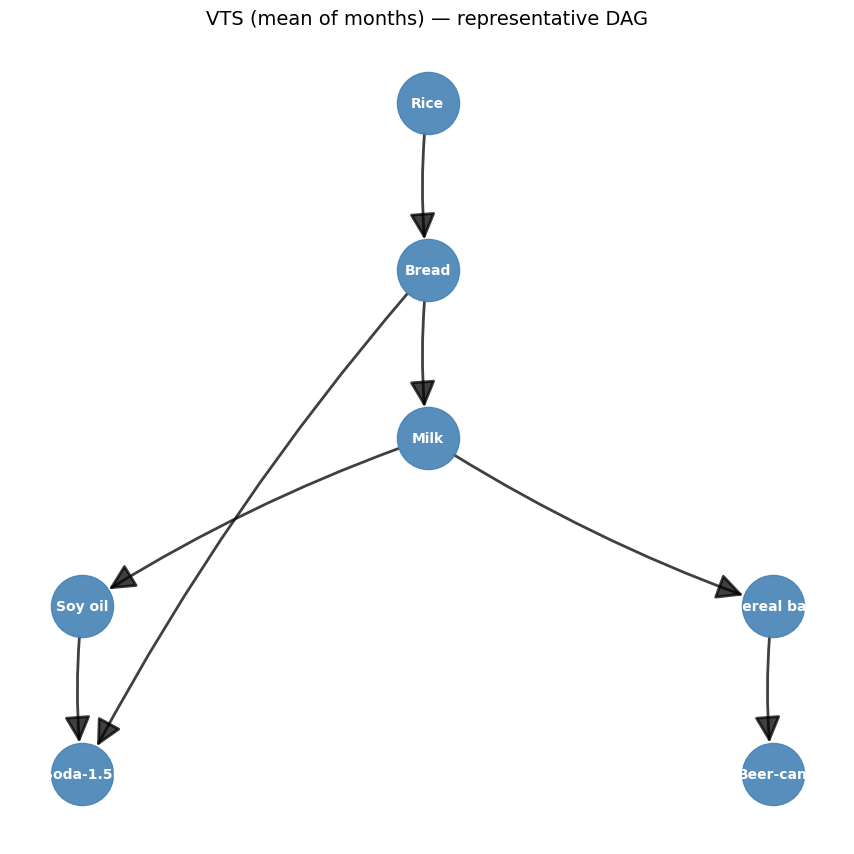

IS consensus edges (τ = 0.5): 2


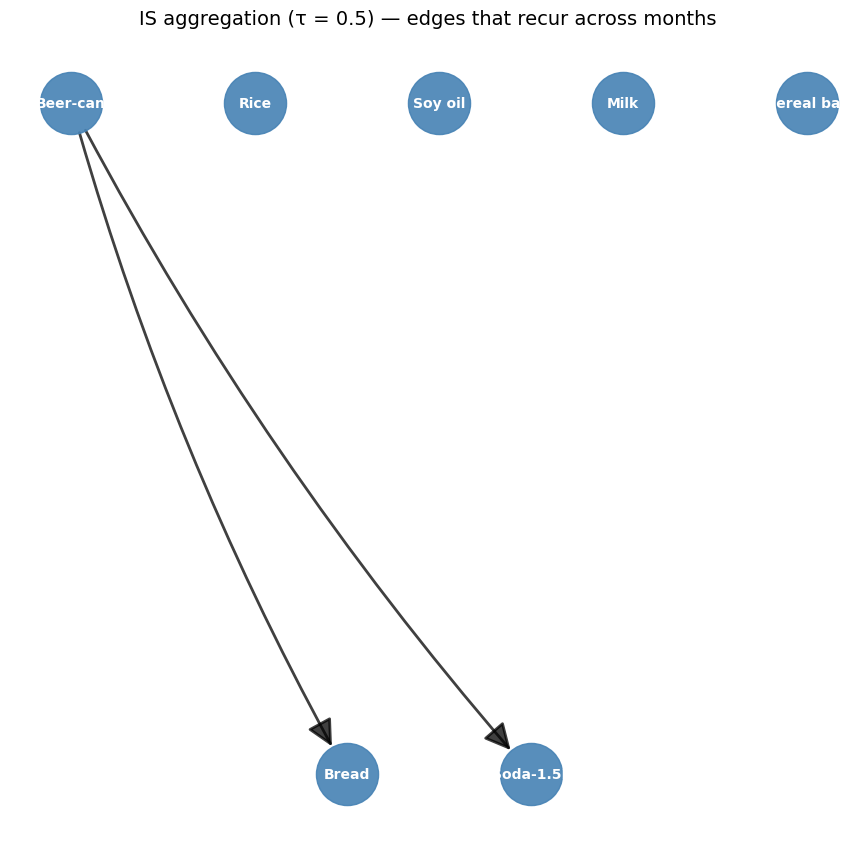

In [ ]:
individuals_m = fit_individual_structures(
    subjects_m,
    method="hc",
    nbf=NBF_MONTHLY,
    node_names=monthly_labels,
    subject_ids=subject_ids_m,
    n_jobs=-1,
    verbose=False,
)
print("edges per month:", {sid: int(np.sum(m.adj_mat)) for sid, m in zip(subject_ids_m, individuals_m)})

vts = compute_vts(subjects_m, method="mean")
vts_df = pd.DataFrame(vts.vts_data, columns=monthly_labels)
vts_mdm = MDM(vts_df, method="hc", nbf=NBF_MONTHLY, verbose=False, n_jobs=-1)
fig = plot_dag(
    vts_mdm,
    node_labels=monthly_labels,
    style="networkx",
    title="VTS (mean of months) — representative DAG",
)
plt.show()

is_view = compute_is(
    [m.adj_mat for m in individuals_m],
    tau=0.5,
    node_names=monthly_labels,
)
print("IS consensus edges (τ = 0.5):", int(np.sum(is_view.adj_mat)))
fig = plot_dag(
    is_view,
    node_labels=monthly_labels,
    style="networkx",
    title="IS aggregation (τ = 0.5) — edges that recur across months",
)
plt.show()


VTS answers “what does a typical month look like?” IS answers “which edges
show up in most months?” Edges that appear in VTS but not in IS are average
effects that are not stable month to month — useful when planning a promotion
that should work in both January and June.

Food-group GS uses a different split: five baskets of three SKUs each. Node
labels (`SKU1`–`SKU3`) are generic because the products differ; distance
compares *shape* of the local networks, not named edges.


{'n_subjects': 5, 'n_nodes': 3, 'node_names': ['SKU1', 'SKU2', 'SKU3'], 'subject_ids': ['Alcoolicas', 'Nao-alcoolicas', 'Cereais_Padaria', 'Leite_Conservas', 'Conservas_Biscoitos'], 'T_per_subject': [180, 180, 180, 180, 180], 'T_min': 180, 'T_max': 180, 'shapes': [(180, 3), (180, 3), (180, 3), (180, 3), (180, 3)]}


,SKU1,SKU2,SKU3
Alcoolicas,Cerveja|Lata,Cerveja|Latao,Cerveja|Retornavel 250ml
Nao-alcoolicas,Refrigerante|Retornavel 1.5L,Refrigerante|Lata,Suco_Natural|1L
Cereais_Padaria,Arroz|5kg,Feijao|1kg,Pao|Forma
Leite_Conservas,Leite|Integral,Iogurte|Natural,Oleo_Soja|1L
Conservas_Biscoitos,Molho_Tomate|250g,Cereal_Barra|250g,Chocolate|Leite 1kg


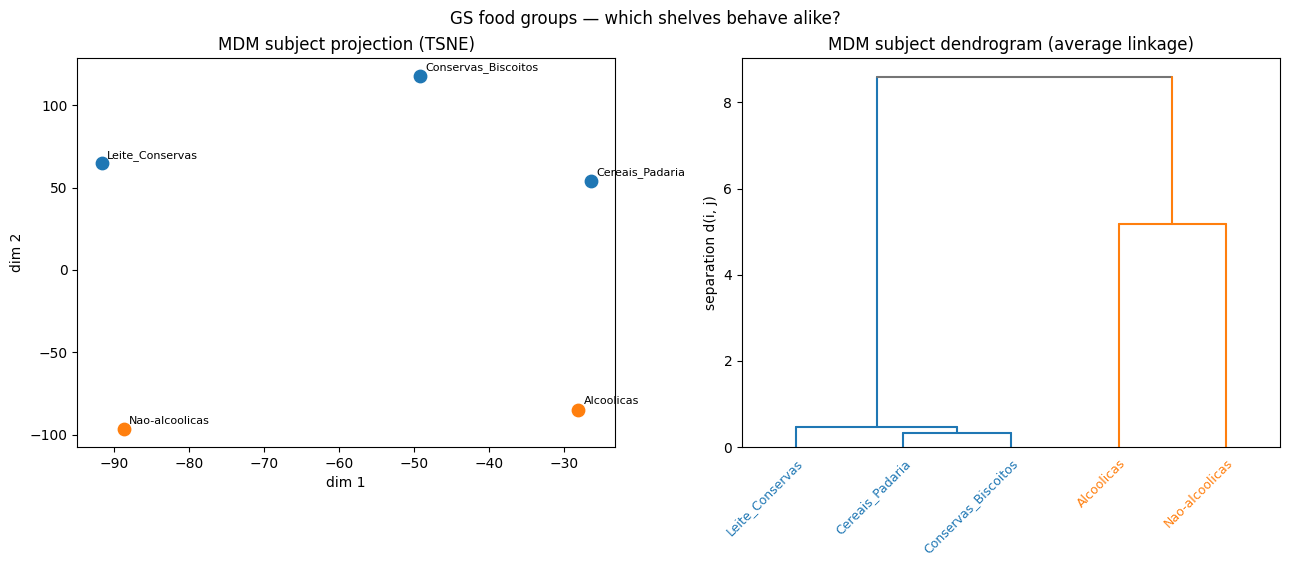

clusters: {'Alcoolicas': 2, 'Nao-alcoolicas': 2, 'Cereais_Padaria': 1, 'Leite_Conservas': 1, 'Conservas_Biscoitos': 1}


In [20]:
subjects_f, subject_ids_f, node_names_f, membership = food_group_subjects(sales)
print(cohort_summary(subjects_f, subject_ids_f, node_names_f))
display(pd.DataFrame(membership, index=node_names_f).T)

individuals_f = fit_individual_structures(
    subjects_f,
    method="hc",
    nbf=NBF,
    node_names=node_names_f,
    subject_ids=subject_ids_f,
    n_jobs=-1,
    verbose=False,
)
dist_f = compute_gs(
    individuals_f,
    metric="lpl_separation",
    nbf=NBF,
    node_names=node_names_f,
    subject_ids=subject_ids_f,
    verbose=False,
)

fig = plot_mdp(dist_f, technique="tsne", n_clusters=2, random_state=0)
plt.suptitle("GS food groups — which shelves behave alike?", y=1.02)
plt.show()

labels_f = suggest_clusters(dist_f, max_clusters=4)
print("clusters:", dict(zip(subject_ids_f, labels_f.tolist())))


## 8. Back to the manager

The 15-SKU MDM is the baseline assortment network: contemporaneous
relationships among packs, with discount factors that say how fast those
relationships may move. Stream, marginal, and anomaly plots turn that graph
into an item-level briefing — who explains whom, and which days broke the
forecast.

Varying the view is the decision layer:

- **Smoothed vs filtered** coefficients change how noisy the briefing looks,
  not which DAG was learned.
- **A second SKU** shows whether a family shares a mechanism or only a shelf.
- **Class / family aggregation** is the right model when the question is aisle
  demand rather than pack substitution.
- **Months (VTS / IS)** test whether a promotion idea is seasonal.
- **Food-group GS** clusters shelves that *behave* alike even when the SKUs
  differ.

Use SKU-level MDM for assortment and substitution; use C3 aggregation for
category reviews; use monthly IS when the plan has to survive January and
June. The taxonomy organizes the products — MDMP estimates whether sales
follow that map, or a different one.
